In [ ]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from cycler import cycler

PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

GROUND_TRUTH_DIR = Path(PROJECT_DIR + "/data/ground_truth_files")

color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

true_false_color_palette = {
  "true_fill": "#4195DF",
  "true_outline": "#032B5F",
  "false_fill": "#747474",
  "false_outline": "#2D2D2D",
}

light_colors = [v for k,v in color_palette.items() if "light" in k]
dark_colors  = [v for k,v in color_palette.items() if "dark" in k]
all_colors = [v for k,v in color_palette.items()]

plt.rcParams.update({

    # figure
    "figure.figsize": (8,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

In [ ]:
def finalize_plot(
        title=None,
        xlabel=None,
        ylabel=None,
        legend=True,
        save_path=None,
        dpi=300
    ):
    """
    Standardize and save matplotlib plots.
    
    Parameters
    ----------
    title : str
    xlabel : str
    ylabel : str
    legend : bool
    save_path : str or Path
        Path without extension (PNG + SVG will be saved)
    dpi : int
    """

    ax = plt.gca()

    if title:
        ax.set_title(title, pad=10)

    if xlabel:
        ax.set_xlabel(xlabel)

    if ylabel:
        ax.set_ylabel(ylabel)

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.,
            frameon=False
            )

    # Improve tick spacing
    ax.tick_params(direction="out", length=4, width=1)

    # Slight margins so lines don't touch borders
    ax.margins(x=0.02, y=0.05)

    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)

        plt.savefig(save_path.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
        plt.savefig(save_path.with_suffix(".svg"), bbox_inches="tight")

    plt.show()

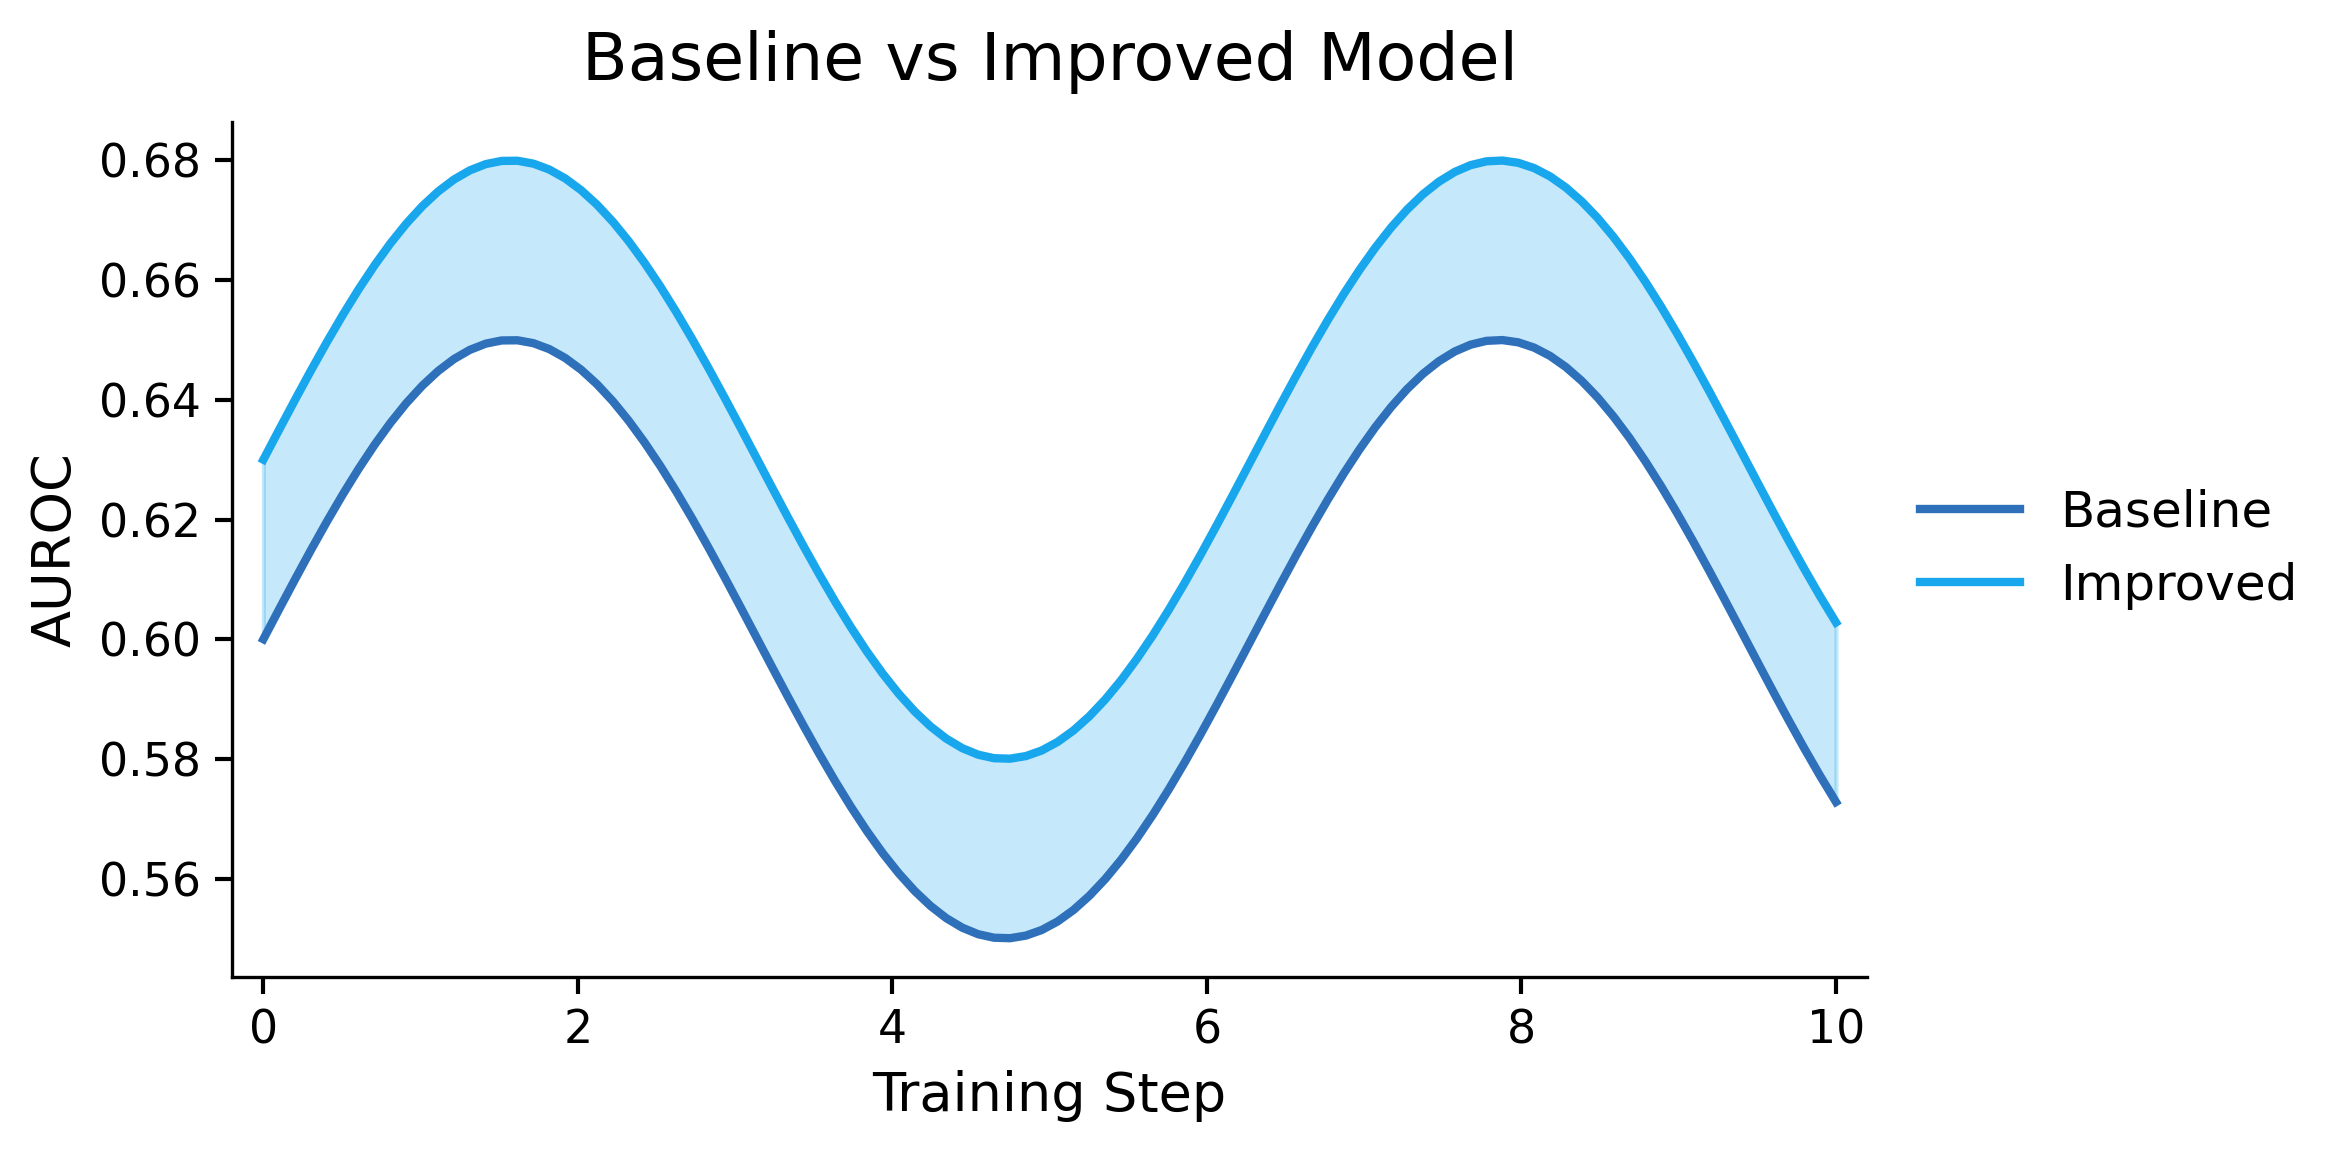

In [63]:
x = np.linspace(0,10,100)

baseline = np.sin(x)*0.05 + 0.60
improved = baseline + 0.03

plt.plot(x, baseline, color=color_palette["blue_dark"], label="Baseline")
plt.plot(x, improved, color=color_palette["blue_light"], label="Improved")

plt.fill_between(
    x,
    baseline,
    improved,
    color=color_palette["blue_light"],
    alpha=0.25
)

finalize_plot(
    title="Baseline vs Improved Model",
    xlabel="Training Step",
    ylabel="AUROC",
)

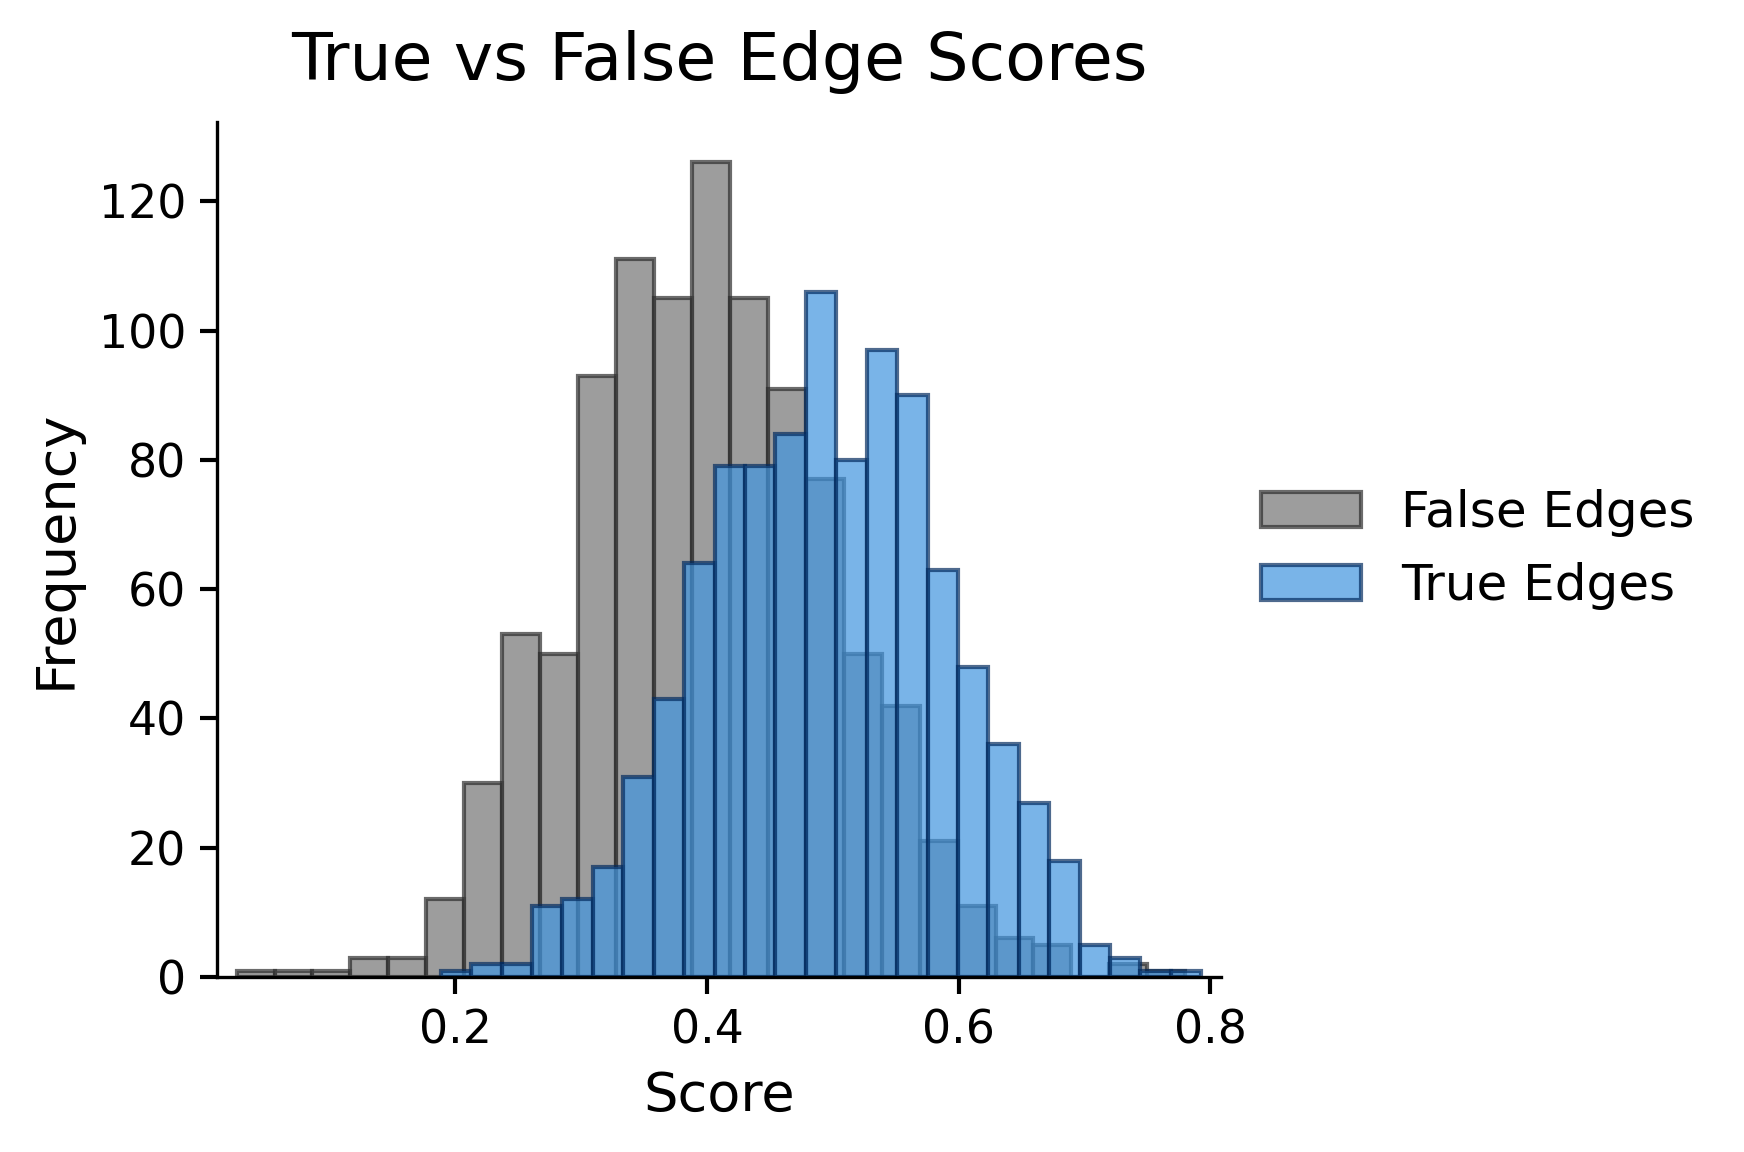

In [74]:
true_false_color_palette = {
  "true_fill": "#4195DF",
  "true_outline": "#032B5F",
  "false_fill": "#747474",
  "false_outline": "#2D2D2D",
}

plt.rcParams['axes.prop_cycle'] = cycler(color=true_false_color_palette.values())

true_scores = np.random.normal(loc=0.5, scale=0.1, size=1000)
false_scores = np.random.normal(loc=0.4, scale=0.1, size=1000)

fig = plt.figure(figsize=(6,4), dpi=300)

plt.hist(false_scores,
         bins=25,
         color=true_false_color_palette["false_fill"],
         edgecolor=true_false_color_palette["false_outline"],
         alpha=0.7,
         label="False Edges"
         )

plt.hist(true_scores,
         bins=25,
         color=true_false_color_palette["true_fill"],
         edgecolor=true_false_color_palette["true_outline"],
         alpha=0.7,
         label="True Edges"
         )

finalize_plot(
    title="True vs False Edge Scores",
    xlabel="Score",
    ylabel="Frequency",
)


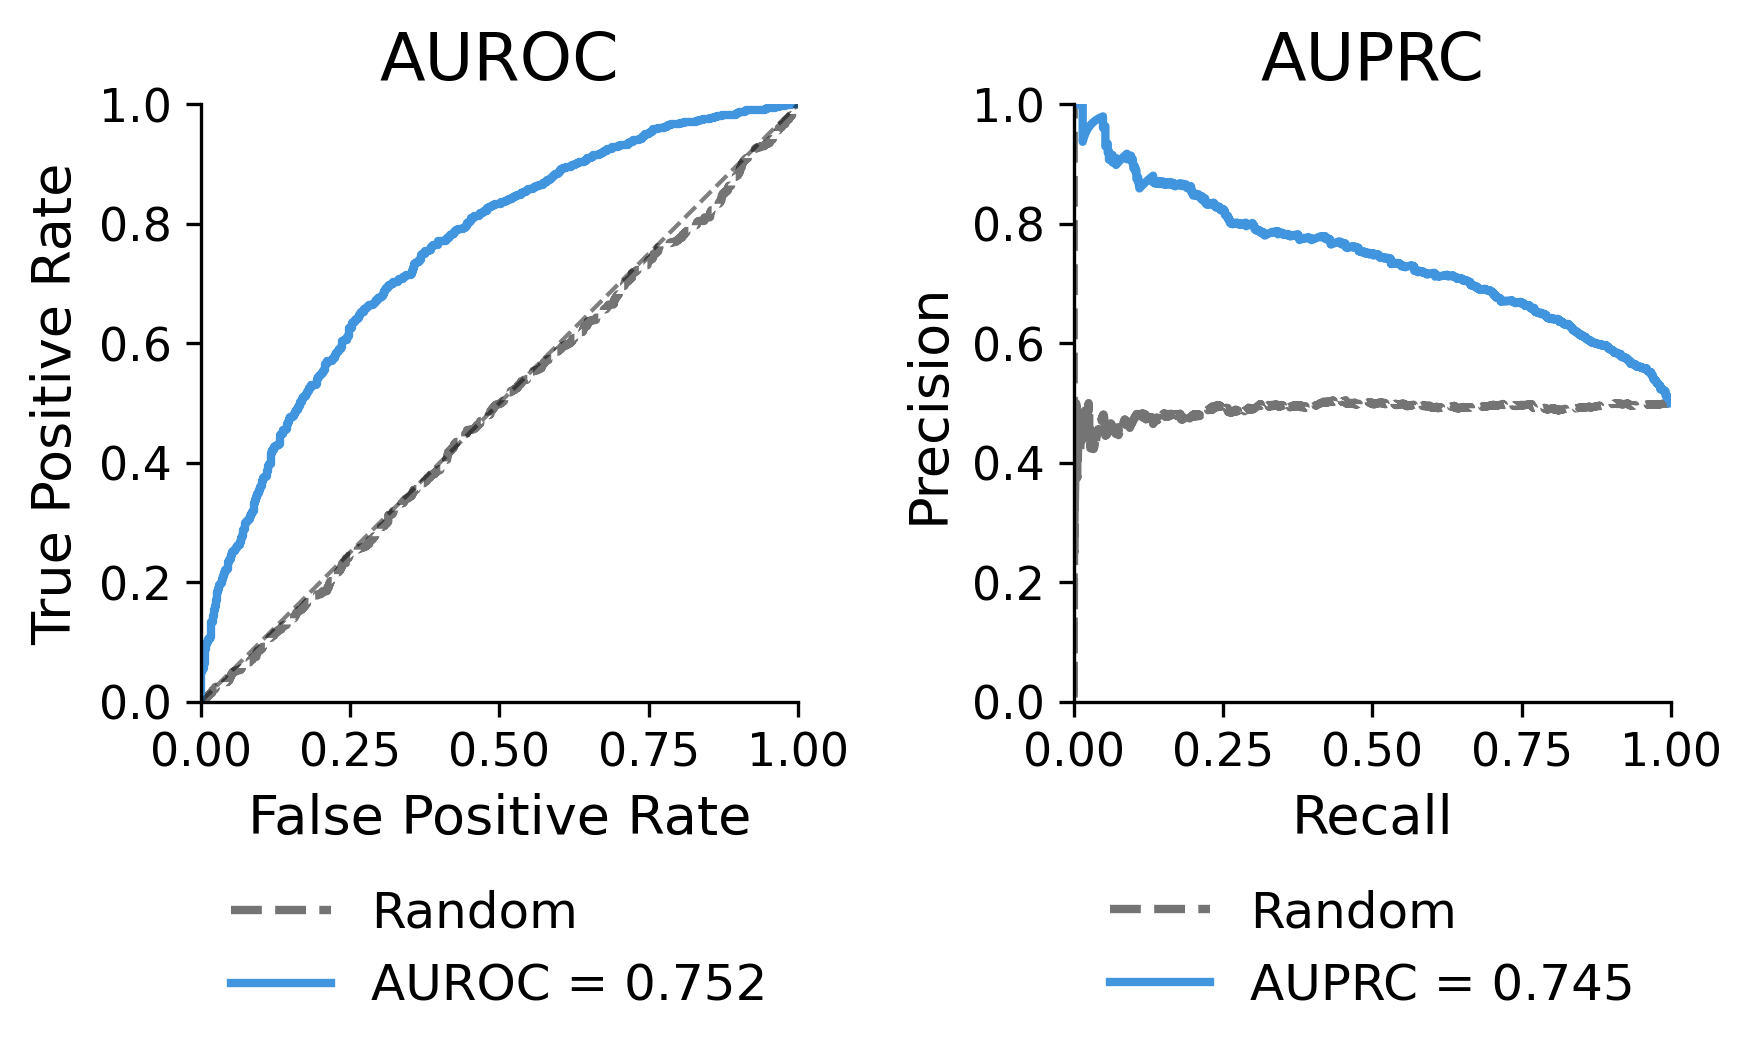

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve

true_false_color_palette = {
  "true_fill": "#4195DF",
  "true_outline": "#032B5F",
  "false_fill": "#747474",
  "false_outline": "#2D2D2D",
}

def create_random_distribution(scores, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    arr = np.asarray(scores)
    return rng.uniform(arr.min(), arr.max(), size=arr.shape[0])

np.random.seed(0)

true_scores = np.random.normal(loc=0.5, scale=0.1, size=1000)
false_scores = np.random.normal(loc=0.4, scale=0.1, size=1000)

# Binary ground-truth labels: 1 for true, 0 for false
y = np.concatenate([
    np.ones(len(true_scores), dtype=int),
    np.zeros(len(false_scores), dtype=int)
])

# Model scores
s = np.concatenate([true_scores, false_scores])

auroc = roc_auc_score(y, s)
fpr, tpr, _ = roc_curve(y, s)
rand_fpr, rand_tpr, _ = roc_curve(y, create_random_distribution(s))

auprc = average_precision_score(y, s)
prec, rec, _ = precision_recall_curve(y, s)
rand_prec, rand_rec, _ = precision_recall_curve(y, create_random_distribution(s))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 4))

# ROC
ax[0].plot(
    rand_fpr, rand_tpr,
    color=true_false_color_palette["false_fill"],
    linestyle="--",
    label="Random"
)
ax[0].plot(
    fpr, tpr,
    color=true_false_color_palette["true_fill"],
    label=f"AUROC = {auroc:.3f}"
)
ax[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("AUROC")
ax[0].legend(
    bbox_to_anchor=(0.5, -0.28),
    loc="upper center",
    borderaxespad=0.0
)
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].set_aspect("equal", adjustable="box")


# PR
ax[1].plot(
    rand_rec, rand_prec,
    color=true_false_color_palette["false_fill"],
    linestyle="--",
    label="Random"
)
ax[1].plot(
    rec, prec,
    color=true_false_color_palette["true_fill"],
    label=f"AUPRC = {auprc:.3f}"
)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("AUPRC")
ax[1].legend(
    bbox_to_anchor=(0.5, -0.28),
    loc="upper center",
    borderaxespad=0.0
)
ax[1].set_ylim(0, 1)
ax[1].set_xlim(0, 1)
ax[1].set_aspect("equal", adjustable="box")

# plt.suptitle("Example ROC and PRC Curves")
plt.tight_layout()
plt.show()

### Comparing Multiple GRN AUROC Curves (main palette)

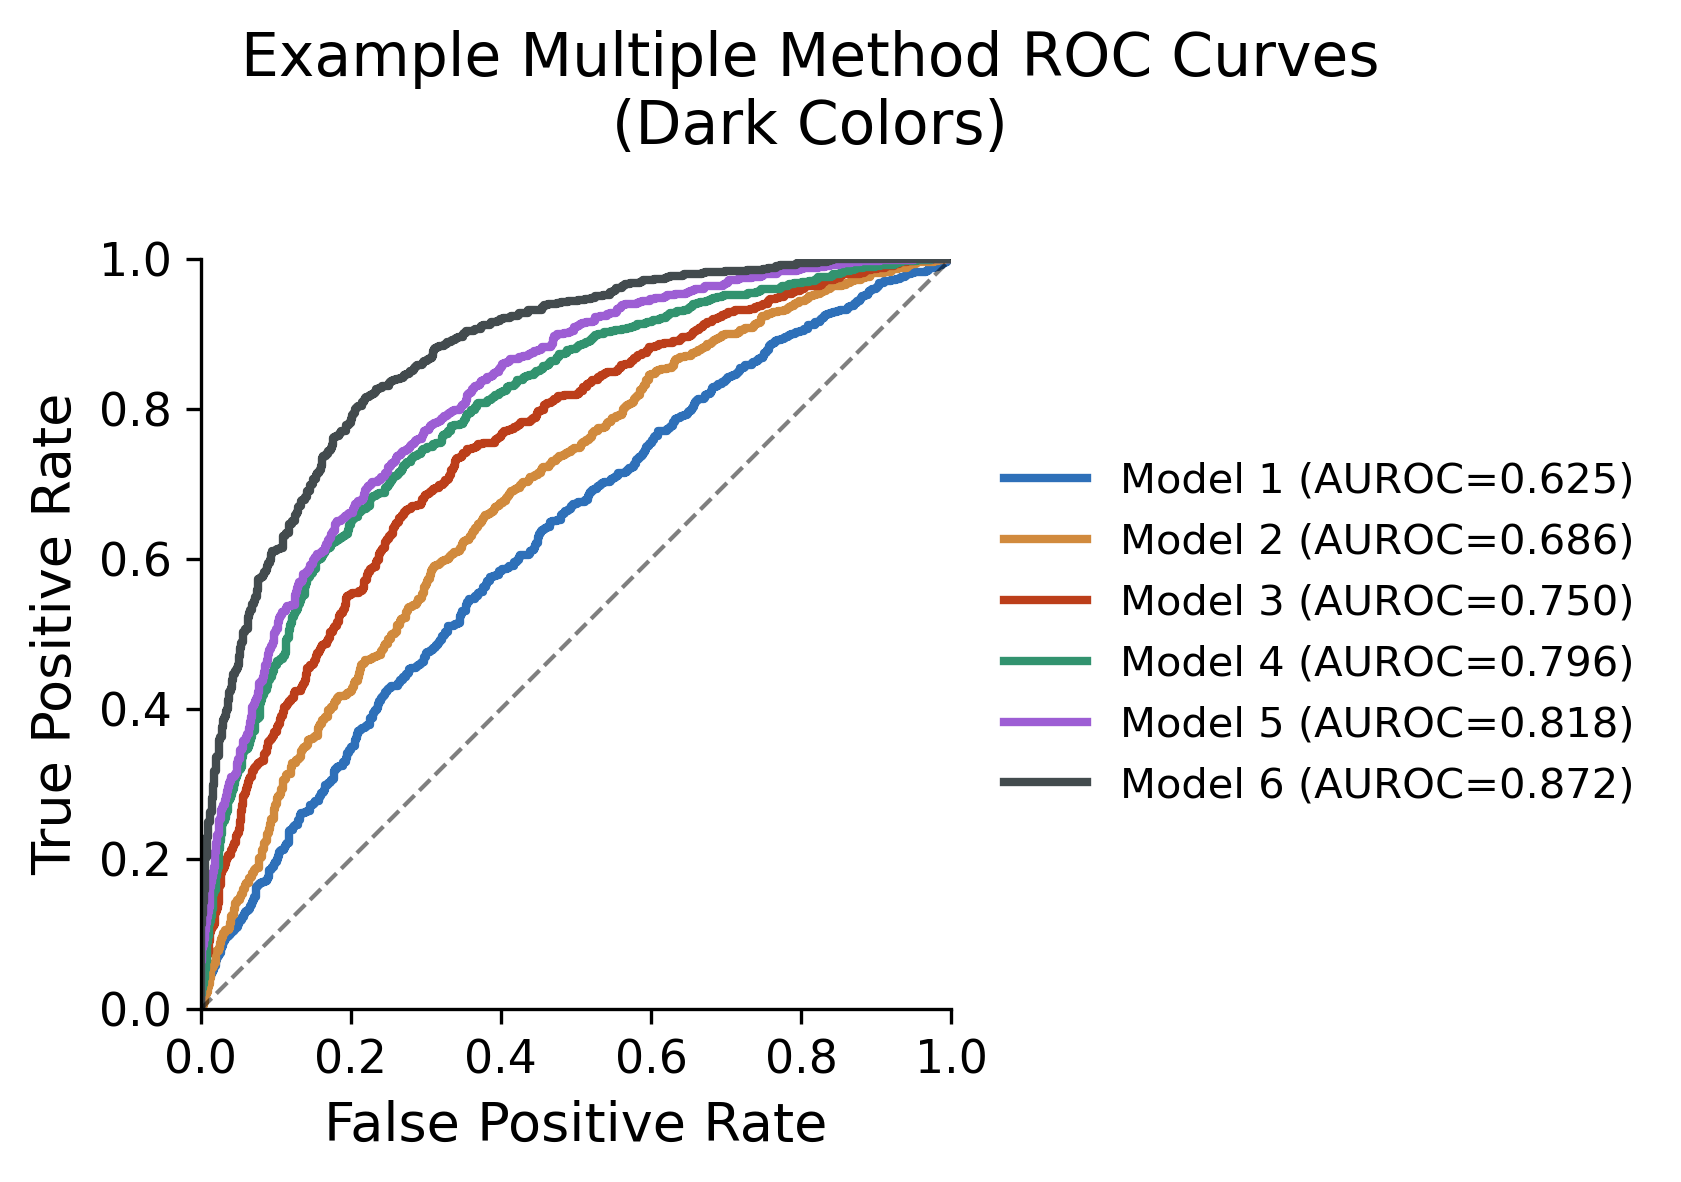

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

dark_colors  = [v for k,v in color_palette.items() if "dark" in k]
light_colors  = [v for k,v in color_palette.items() if "light" in k]
plt.rcParams['axes.prop_cycle'] = cycler(color=dark_colors)

np.random.seed(0)

fig, ax = plt.subplots(figsize=(6,4))

aurocs = []

for i in range(6):

    # Slightly change separation each time
    true_scores = np.random.normal(loc=0.50 + 0.02*i, scale=0.1, size=1000)
    false_scores = np.random.normal(loc=0.45, scale=0.1, size=1000)

    y = np.concatenate([
        np.ones(len(true_scores)),
        np.zeros(len(false_scores))
    ])

    s = np.concatenate([true_scores, false_scores])

    auroc = roc_auc_score(y, s)
    aurocs.append(auroc)

    fpr, tpr, _ = roc_curve(y, s)

    ax.plot(
        fpr,
        tpr,
        label=f"Model {i+1} (AUROC={auroc:.3f})"
    )

# Random baseline
ax.plot([0,1], [0,1], "k--", lw=1, alpha=0.5)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.suptitle("Example Multiple Method ROC Curves")
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    fontsize=10,
)
plt.suptitle("Example Multiple Method ROC Curves\n(Dark Colors)")

plt.tight_layout()
plt.show()